<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Stochastic-modeling-and-derivatives---TD-4" data-toc-modified-id="Stochastic-modeling-and-derivatives---TD-4-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Stochastic modeling and derivatives - TD 4</a></span><ul class="toc-item"><li><span><a href="#Exercice-1:-Simulation-de-la-couverture-dans-le-modèle-de-Black-Scholes" data-toc-modified-id="Exercice-1:-Simulation-de-la-couverture-dans-le-modèle-de-Black-Scholes-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Exercice 1: Simulation de la couverture dans le modèle de Black-Scholes</a></span><ul class="toc-item"><li><span><a href="#Q1:-simulation-des-trajectoires-du-sous-jacent" data-toc-modified-id="Q1:-simulation-des-trajectoires-du-sous-jacent-1.1.1"><span class="toc-item-num">1.1.1&nbsp;&nbsp;</span>Q1: simulation des trajectoires du sous-jacent</a></span></li><li><span><a href="#Q2:-simulation-du-portefeuille-de-couverture" data-toc-modified-id="Q2:-simulation-du-portefeuille-de-couverture-1.1.2"><span class="toc-item-num">1.1.2&nbsp;&nbsp;</span>Q2: simulation du portefeuille de couverture</a></span><ul class="toc-item"><li><span><a href="#Q2-(a)---Les-formules" data-toc-modified-id="Q2-(a)---Les-formules-1.1.2.1"><span class="toc-item-num">1.1.2.1&nbsp;&nbsp;</span>Q2 (a) - Les formules</a></span></li><li><span><a href="#Q2-(b)" data-toc-modified-id="Q2-(b)-1.1.2.2"><span class="toc-item-num">1.1.2.2&nbsp;&nbsp;</span>Q2 (b)</a></span></li></ul></li></ul></li></ul></li></ul></div>

# Stochastic modeling and derivatives - TD 4

## Exercice 1: Simulation de la couverture dans le modèle de Black-Scholes

In [1]:
import numpy as np

Le but de cet exercice est de simuler le comportement du portefeuille de couverture en delta d'une option lorsque l'actif S suit la dynamique du modèle de Black-Scholes. L'actif paye un taux de dividende/repo. 
Tous les paramètres $\sigma, \mu, r, q$ sont supposés constants en temps.

### Q1: simulation des trajectoires du sous-jacent

$\bullet$ Pour rappel: dans le modèle de Black-Scholes avec paramètre de drift $\mu \in \mathbb{R}$ et paramètre de volatilité $\sigma > 0$, la dynamique du cours du sous-jacent est donnée par 

$$
S_t = S_0 \exp \left( \mu \, t - \frac 12 \sigma^2 t + \sigma W_t \right), \qquad t \ge 0,
$$

où $(W_t)_{t \ge 0}$ est un mouvement Brownien.

$\bullet$ Si l'on veut simuler la variable $S_T$ pour une date future $T$ fixée, il suffira de simuler le mouvement Brownien $W_T$ à la même date, ensuite prendre l'exponentielle.

$\bullet$ Si l'on veut simuler toute la trajectoire future $(S_{t_0}, S_{t_1}, \dots, S_{t_n})$ sur un certain nombre de dates $(t_0, t_1, \dots, t_n)$ (par exemple $n = 125$ jours sur un horizon de $T = t_n = 0.5$ années), on pourra utiliser la relation de récurrence

$$
\begin{aligned}
&S_{t_{i+1}} = S_{t_i} \frac{S_{t_{i+1}}}{S_{t_i}}
= S_{t_i} \ \times \ ????
\\
&\leadsto \mbox{TO DO: remplacer le rapport $\frac{S_{t_{i+1}}}{S_{t_i}}$ par une fonction explicite de } W_{t_{i+1}} - W_{t_i}
\end{aligned}
$$
 
que l'on interprète de la manière suivante: en ayant simulé la valeur $S_{t_i}$, il suffit de simuler le nouvel accroissement Brownien $(W_{t_{i+1}} - W_{t_i})$ afin d'obtenir la valeur suivante $S_{t_{i+1}}$, en multipliant par le bon facteur exponentiel.

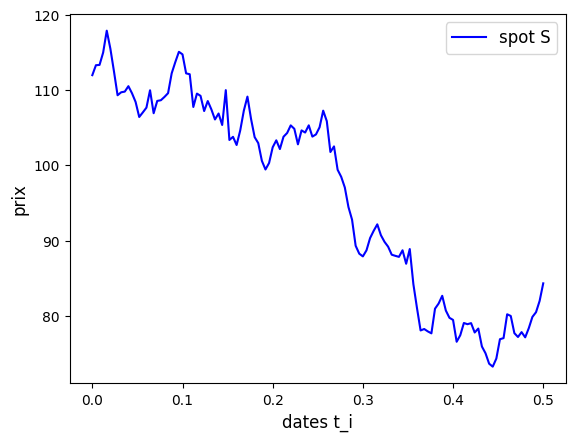

In [2]:
## Paramètres Black-Scholes
mu = 0.05
q = 0.03
sigma = 0.3
S_0 = 112

## Horizon temps
T = 0.5

## Dates t_1, ..., t_n
n = 125
dates = np.linspace(0, T, n+1)

Delta_T = T/n

################################
## Simulation trajectoire de S
################################
# On initialise une trajectoire à n+1 points 
S = S_0 * np.ones(n+1)

for i in range(n):
    ## Tirage d'une gaussiennes centrée et de variance=1
    G = np.random.randn()
    
    ##############################################################
    ## TO DO: générer l'accroissement Brownien sur [t_i, t_{i+1}]
    ## à partir de G.
    ## Il faudra multiplier G par la bonne valeur de l'écart-type
    ##############################################################
    accr_brownien =  np.sqrt(Delta_T) * G # modifier
    
    ############################################################
    ## TO DO: compléter la simulation de la trajectoire de S
    ############################################################
    S[i+1] = S[i] * np.exp((mu - 0.5 * sigma**2) * Delta_T + sigma * accr_brownien) # modifier 

######################################
## Affichage de la trajectoire de S
######################################
import matplotlib.pyplot as plt

plt.plot(dates, S, color="b", label="spot S")

plt.xlabel("dates t_i", fontsize=12)
plt.ylabel("prix", fontsize=12)

plt.legend(loc="best", fontsize=12)

### Q2: simulation du portefeuille de couverture

$\bullet$ On souhaite simuler la comportement du portefeuille de couverture d'un call $(S_T - K)^+$ dans le cas de rebalancement du portefeuille (ajustement du $\delta$) aux dates discrètes $(t_0, t_1, \dots, t_n)$.

$\bullet$ L'évolution  du portefeuille est analogue au cas du modèle binomial: ce qui change, c'est le calcul du delta à chaque date.

$\bullet$ Pour rappel: le portefeuille a une composante $\pi^0$ dans l'actif sans risque, et une composante delta dans l'actif risqué S:

$$
V_{t_i} = \pi^0_{t_i} + \delta_{t_i} S_{t_i}.
$$

La valeur à la date $t_{i+1}$ est

$$
V_{t_{i+1}} = \pi^0_{t_i} e^{r \, \Delta T} + \delta_{t_i} S_{t_{i+1}} + \delta_{t_i} S_{t_{i}} (e^{q \, \Delta T}-1)
$$

où $\Delta T$ est le pas de temps entre $t_i$ et $t_{i+1}$. Ainsi, la variation de valeur du portefeuille est donnée par

$$
\begin{aligned}
V_{t_{i+1}} - V_{t_i} &= \pi^0_{t_i} \, (e^{r \, \Delta T}-1) + \delta_{t_i} ( S_{t_{i+1}} - S_{t_i} )+\delta_{t_i} S_{t_{i}} (e^{q \, \Delta T}-1)
\\
&= (V_{t_i} - \delta_{t_i} S_{t_i}) \, (e^{r \, \Delta T}-1) + \delta_{t_i} ( S_{t_{i+1}} - S_{t_i} )+\delta_{t_i} S_{t_{i}} (e^{q \, \Delta T}-1).
\end{aligned}
$$

$\bullet$ Nous avons besoin de déterminer:

+ la valeur initiale $V_0$

+ la quantité de la position delta $\delta_{t_i} = \delta(t_i, S_{t_i})$ à garder entre $t_i$ et $t_{i+1}$.

A chaque date $t_i$, le montant à placer dans l'actif sans risque est donné par $V_{t_i} - \delta_{t_i} S_{t_i}$.

#### Q2 (a) - Les formules

$\bullet$ Coder la formule de Black-Scholes pour le prix $\mathrm{Call_{BS}}(t,S,T,K)$ de l'option (afin d'évaluer $V_0$), et la formule pour le delta $\delta_\mathrm{BS}(t,S,T,K)$, que l'on rappelle ici:

$$
\begin{aligned}
\mathrm{Call_{BS}}(t,S,T,K,\sigma) &= e^{-r \, (T-t)} \bigl( F_t^T\, N(d_1) - K \, N(d_2) \bigr),
\\
\delta_\mathrm{BS}(t,S,T,K, \sigma) &= e^{-q \, (T-t)} N(d_1)
\end{aligned}
$$

où $F_t^T = S \, e^{(r-q) \, (T-t)}$ est le prix forward de $S$,

$$
d_1 = \frac 1{\sigma \sqrt{T-t}} \log \frac{F_t^T}K + \frac 12 \sigma \sqrt{T-t},
\qquad
d_2 = d_1 - \sigma \sqrt{T-t},
$$

et $N(x) = \int_{-\infty}^x \frac 1{\sqrt{2 \pi}} e^{-\frac{y^2} 2} dy$ est la fonction de répartition gaussienne.

In [3]:
def compute_sigma_BS(period, volatility):
    integral = 0
    total_time = 0
    for i in range(len(period)):
        total_time += period[i]
        integral += period[i] * volatility[i]**2
    print(integral)
    print(total_time)
    return np.sqrt(integral/total_time)

period = [1/12, 1/12, 1/12, 3/12, 5/12]
volatility = [0.202000, 0.178000, 0.152000, 0.130000, 0.105000]

compute_sigma_BS(period, volatility)

0.01678475
0.9166666666666667


np.float64(0.1353168000051596)

In [4]:
## Nous allons utiliser la fonction de repartition gaussienne norm.cdf
## de la librairie scipy.stats
import scipy.stats as sps

# formule générique si 
# Z est une variable gaussienne de moyenne m−V/2
# et de variance V
def Call_BS_generic(x, m, V, K):
    d1 = d1 = np.log(x * np.exp(m) / K) / np.sqrt(V) + np.sqrt(V) / 2
    d2 = d1 - np.sqrt(V)
    return x * np.exp(m) * sps.norm.cdf(d1) - K * sps.norm.cdf(d2)



def Call_BS(t, S_t, T, K, r, q, sigma):
    sigma_sqrt_time = sigma * np.sqrt(T - t)
    #######################################################
    ## TO DO: compléter avec le calcul du prix du call BS
    #######################################################
    F_t = S_t * np.exp((r-q)*(T-t))
    d1 = (1/sigma_sqrt_time) * np.log(F_t/K) + 0.5 * sigma_sqrt_time
    d2 = d1 - sigma_sqrt_time
    price = np.exp(-r * (T-t)) * (F_t * sps.norm.cdf(d1) - K * sps.norm.cdf(d2))
    delta = np.exp(-q * (T-t)) * sps.norm.cdf(d1)
    vega = S_t * np.exp(-q * (T-t)) * np.sqrt(T-t) * sps.norm.pdf(d1)
    gamma = vega / (S_t**2 * sigma * (T-t))
    theta = - S_t * np.exp(-q * (T-t)) * sigma * sps.norm.pdf(d1) / (2 * np.sqrt(T-t)) + q * S_t * np.exp(-q * (T-t)) * sps.norm.cdf(d1) - r * K * np.exp(-r * (T - t)) * sps.norm.cdf(d2)
    rho = (T-t) * K * np.exp(-r*(T-t)) * sps.norm.cdf(d2)

    return {'price':price, 'delta':delta, 'vega':vega, 'gamma':gamma, 'theta':theta, 'rho':rho} 

def Put_BS(t, S_t, T, K, r, q, sigma):
    sigma_sqrt_time = sigma * np.sqrt(T - t)
    #######################################################
    ## TO DO: compléter avec le calcul du prix du call BS
    #######################################################
    F_t = S_t * np.exp((r-q)*(T-t))
    d1 = (1/sigma_sqrt_time) * np.log(F_t/K) + 0.5 * sigma_sqrt_time
    d2 = d1 - sigma_sqrt_time
    price = np.exp(-r * (T-t)) * (K * sps.norm.cdf(-d2) - F_t * sps.norm.cdf(-d1))

    delta = -np.exp(-q * (T-t)) * sps.norm.cdf(-d1) 
    vega = S_t * np.exp(-q * (T-t)) * np.sqrt(T-t) * sps.norm.pdf(d1)
    gamma = vega / (S_t**2 * sigma * (T-t))
    theta = - S_t * np.exp(-q * (T-t)) * sigma * sps.norm.pdf(d1) / (2 * np.sqrt(T-t)) - q * S_t * np.exp(-q * (T-t)) * sps.norm.cdf(-d1) + r * K * np.exp(-r * (T - t)) * sps.norm.cdf(-d2)
    rho = -(T-t) * K * np.exp(-r*(T-t)) * sps.norm.cdf(-d2)

    return {'price':price, 'delta':delta, 'vega':vega, 'gamma':gamma, 'theta':theta, 'rho':rho} 

In [16]:
import pandas as pd

t = 0.0
S_t = 101.020000
T = 0.526000
K = 97.250000
r = 0.008000
q = 0.044000
sigma = 0.227900

x = S_t
m = (r-q) * (T - t)
V = sigma**2 * (T - t)

print(Call_BS_generic(x, m, V, K) * np.exp(-r * (T - t)))

call_series =pd.Series(Call_BS(t, S_t, T, K, r, q, sigma), name='Call')
put_series = pd.Series(Put_BS(t, S_t, T, K, r, q, sigma), name='Put')
result = pd.DataFrame([call_series, put_series]).T
result['Call Put Parity'] = result['Call'] - result['Put']
result

7.416386687363431


,Call,Put,Call Put Parity
price,7.416387,5.549177,1.867209
delta,0.565314,-0.411808,0.977122
vega,28.004641,28.004641,0.000000
gamma,0.022892,0.022892,0.000000
theta,-3.951566,-7.520022,3.568456
rho,26.137786,-24.800913,50.938698


In [17]:
# We consider a Call option, in the Black-Scholes model with the parameters S0=105.980000,T=0.383000,K=94.300000,r=0.006000,q=0.095000,σ=0.121900
# . We would like to hedge the option with the Future on S with maturity T′=0.217000
# . How many Futures should we buy now at t=0
# ? (expected accuracy = 0.001)
T_prime = 0.215000
N = result['Call']['delta'] / np.exp((r-q)*T_prime)
N

np.float64(0.5697062516168462)

$\bullet$ Compléter le code de simulation ci-dessous.

,Date,Spot,Unnamed: 2,Valeur_finale
0,0.000000,95.030000,NaN,4.017964
1,0.005436,94.922331,NaN,3.980151
2,0.010873,94.541017,NaN,3.850019
3,0.016309,95.321082,NaN,4.106910
4,0.021746,93.439096,NaN,3.457425
...,...,...,...,...
177,0.962254,83.187228,NaN,-0.197391
178,0.967691,86.307493,NaN,-0.197399
179,0.973127,88.848660,NaN,-0.197406
180,0.978564,86.316401,NaN,-0.197414


Valeur finale V_T = -0.197
Payoff (S_T - K)^+ = 0.000
Valeur du portefeuille delta hedged = -0.197


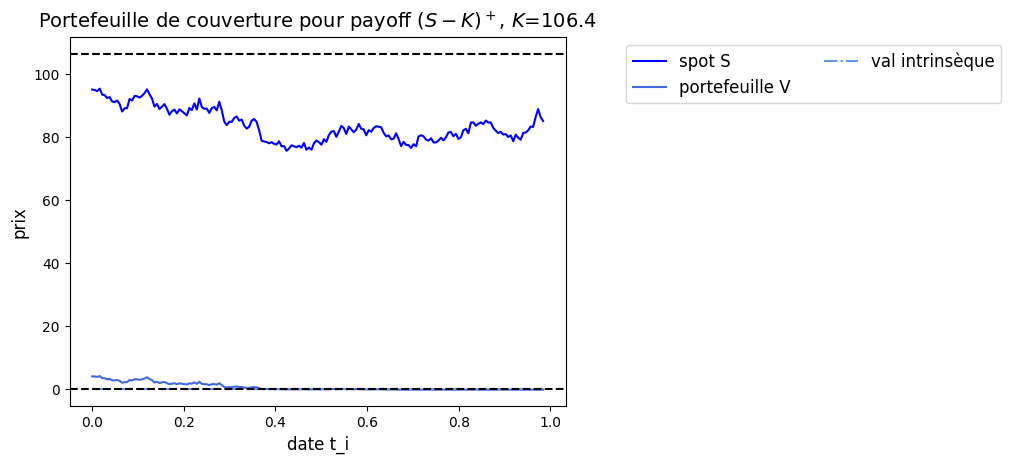

In [7]:
## Paramètres du call 
T = 0.984000
K = 106.430000
r = 0.007000
mu = r
q = 0.0
sigma = 0.209100

def payoff_call(S):
    return np.maximum(S - K, 0)


data = pd.read_csv('download.csv', delimiter=';')

dates = data['Date']
S = data['Spot']
n = data.shape[0]

################################################
## Portefeuille de couverture construit sur la
## trajectoire du sous-jacent simulée ci-dessus
################################################
i = 0

V_0 = Call_BS(t=0, S_t=S[i], T=T, K=K, r=r, q=q, sigma=sigma)['price']

## On initialise le vecteur qui contiendra les valeurs du portefeuille V
V = V_0 * np.ones(n)

for i in range(n-1):

    delta = Call_BS(t=dates[i], S_t=S[i], T=T, K=K, r=r, q=q, sigma=sigma)['delta']
    
    current_cash = V[i] - delta*S[i]
    Delta_T = dates[i+1] - dates[i]

    ## On calcule la variation du portefeuille, V_{t_{i+1}} - V_{t_i}
    evolution_portefeuille = current_cash * (np.exp(r * Delta_T)-1) + delta * (S[i+1] - S[i] + S[i] * (np.exp(q * Delta_T)-1))
    
    V[i+1] = V[i] + evolution_portefeuille

###################################################
## On compare la valeur terminale du portefeuille V
## et le payoff de l'option
###################################################
data['Valeur_finale'] = V
display(data)
print("Valeur finale V_T = %1.3f" %V[n-1])
print("Payoff (S_T - K)^+ = %1.3f" %payoff_call(S[n-1]))
print("Valeur du portefeuille delta hedged = %1.3f"%(V[n-1]-payoff_call(S[n-1])))
###############
## Affichage
###############
import matplotlib.pyplot as plt

###########################################################
## On affiche la trajectoire du sous-jacent
plt.plot(dates, S, color="b", label="spot S")

###########################################################
## On affiche la trajectoire du portefeuille de couverture
plt.plot(dates, V, color='royalblue', label="portefeuille V")

################################################
## On affiche également la trajectoire de la
## valeur intrinsèque de l'option
val_intrinseque = payoff_call(S)

plt.plot(dates, val_intrinseque, color='cornflowerblue', linestyle='-.', label="val intrinsèque")

plt.axhline(K, linestyle='--', color="k")
plt.axhline(0, linestyle='--', color="k")

plt.xlabel("date t_i", fontsize=12)
plt.ylabel("prix", fontsize=12)
plt.title("Portefeuille de couverture pour payoff $(S - K)^+$, $K$=%1.1f" %K, fontsize=14)

plt.legend(loc=9, fontsize=12, bbox_to_anchor=(1.5, 1.0), ncol=2)

$\bullet$ Qu'observez-vous? La couverture de l'option à maturité est-elle parfaite?
Que se passe-t-il si l'on modifie le nombre de dates de rebalancement du portefeuille?
Et la valeur du drift $\mu$?

In [8]:
# mu n'impacte pas le portfeuille de couverture, en revanche la volatilité fait vraiment bien changé le portefeuille.
# si j'ai overpricé la vol alors je ferai un gain de PnL, si la vol est inférieure, alors je perdrai de la tune.

M = 1000
PL = np.zeros(M)

vol_simulation = 0.2
vol_pricing = 0.3

for m in range(M):
    G = np.random.randn(n)

    ## On multiplie tous les éléments du vecteur G par l'écart-type delta_T 
    accr_brownien = np.sqrt(Delta_T) * G 

    S = S_0 * np.ones(n+1)

    for i in range(n):
        #####################
        ## TO DO: compléter 
        #####################
        S[i+1] = S[i] * np.exp((mu - 0.5 * vol_simulation**2) * Delta_T + vol_simulation * accr_brownien[i])

    ########################################################
    ## Portefeuille de couverture construit à partir 
    ## de la trajectoire du sous-jacent simulée ci-dessus
    ########################################################
    i = 0

    V_0 = Call_BS(t=0, S_t=S_0, T=T, K=K, r=r, q=q, sigma=vol_pricing)

    ## On initialise le vecteur qui contiendra les valeurs du portefeuille V
    V = V_0 * np.ones(n+1)

    for i in range(n):
        #######################################################
        ## TO DO: compléter avec le calcul du delta à la date 
        ## courante t_i = dates[i]
        #######################################################
        delta = delta_BS(t=dates[i], S_t=S[i], T=T, K=K, r=r, q=q, sigma=vol_pricing)

        
        #######################################################
        ## TO DO: compléter avec le calcul de la position cash
        ## à la date courante t_i = dates[i]
        #######################################################
        current_cash = V[i] - delta * S[i]
        
        #######################################################
        ## TO DO: compléter avec la variation du portefeuille
        ## V_{t_{i+1}} - V_{t_i}
        #######################################################
        evolution_portefeuille = current_cash * (np.exp(r * Delta_T) - 1) + delta * (S[i+1] - S[i]) + delta * S[i] * (np.exp(q * Delta_T) - 1)
        
        V[i+1] = V[i] + evolution_portefeuille

    PL[m] = V[n] - payoff_call(S[n])

TypeError: unsupported operand type(s) for *: 'dict' and 'float'

(array([0.04074094, 0.08827203, 0.15277852, 0.21388992, 0.24784071,
        0.3259275 , 0.30895211, 0.34290289, 0.31913735, 0.34290289,
        0.31234719, 0.24784071, 0.18333422, 0.1561736 , 0.08827203,
        0.02376555]),
 array([0.86656653, 1.16111056, 1.45565459, 1.75019862, 2.04474265,
        2.33928668, 2.63383071, 2.92837474, 3.22291877, 3.5174628 ,
        3.81200683, 4.10655085, 4.40109488, 4.69563891, 4.99018294,
        5.28472697, 5.579271  ]),
 <BarContainer object of 16 artists>)

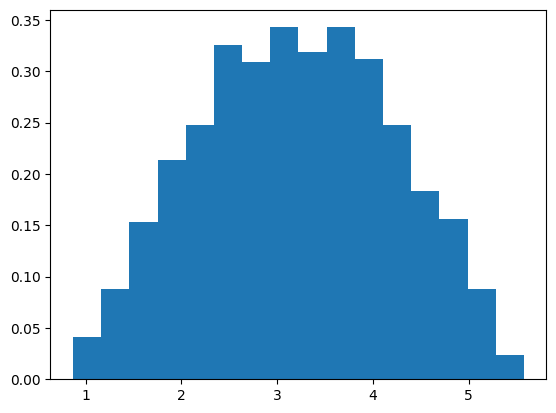

In [ ]:
plt.hist(PL, density=True, bins='auto')

#### Q2 (b)

Evaluer également le prix Black-Scholes théorique de l'option à chaque date: c'est à dire, le prix que l'option aurait si la couverture était parfaite.

On utilisera la même trajectoire déjà simulée pour le sous-jacent.

C:\Users\lione\AppData\Local\Temp\ipykernel_18664\539557599.py:11: RuntimeWarning: divide by zero encountered in divide
  d1 = (1/sigma_sqrt_time) * np.log(F_t/K) + 0.5 * sigma_sqrt_time


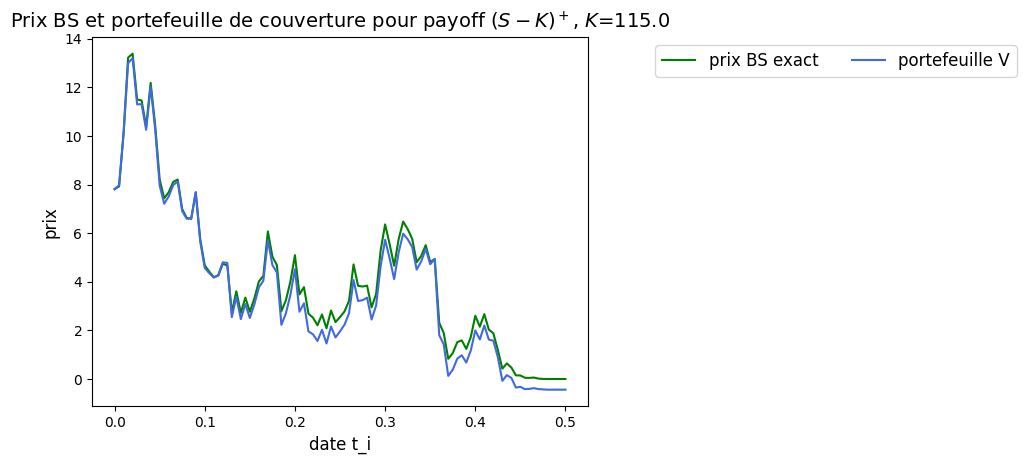

In [ ]:
###################################################################
## TO DO: calculer et afficher la trajectoire du prix BS théorique
###################################################################
prix_exact = Call_BS(dates, S_t=S, T=T, K=K, r=r, q=q, sigma=sigma)

plt.plot(dates, prix_exact, color='g', label="prix BS exact")

############################################################
## On affiche la trajectoire du portefeuille de couverture
plt.plot(dates, V, color='royalblue', label="portefeuille V")

plt.xlabel("date t_i", fontsize=12)
plt.ylabel("prix", fontsize=12)
plt.title("Prix BS et portefeuille de couverture pour payoff $(S - K)^+$, $K$=%1.1f" %K, fontsize=14)

plt.legend(loc=9, fontsize=12, bbox_to_anchor=(1.5, 1.0), ncol=2)